Далее будет сделаны импорты, необходимые для выполнения работы.  В процессе работы иимпорты будут добавляться 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Считаем файл в DataFrame и выведем информацию о нём. Параметр ф-ции read_csv index_col, использовался, что первый столбик сделать индексом(так как это они и есть, если посмотреть на файл).

In [3]:
ds_original = pd.read_csv("../data/V4.csv", index_col=0)
ds_original.info()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer Name        500 non-null    str    
 1   Customer e-mail      500 non-null    str    
 2   Country              500 non-null    str    
 3   Gender               244 non-null    float64
 4   Age                  500 non-null    int64  
 5   Annual Salary        500 non-null    float64
 6   Credit Card Debt     500 non-null    float64
 7   Net Worth            500 non-null    float64
 8   Car Purchase Amount  500 non-null    float64
dtypes: float64(5), int64(1), str(3)
memory usage: 35.3 KB


Теперь посмотрим на о как выглядят значения 

In [4]:
ds_original.head()

,Customer Name,Customer e-mail,Country,Gender,Age,Annual Salary,Credit Card Debt,Net Worth,Car Purchase Amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,USA,0.0,42,62812.09301,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,eu.dolor@diam.co.uk,USA,0.0,41,66646.89292,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,USA,NaN,43,53798.55112,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,malesuada@dignissim.com,USA,NaN,58,79370.03798,14426.164850,548599.0524,67422.36313
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,USA,1.0,57,59729.15130,5358.712177,560304.0671,55915.46248


Тут можно видеть, что некоторые колонки имеют неоптимальный тип данных(например пол - он может быть bool, а не float). Также я уверен, что колонку Country можно отредачить и привести к типу данных int, а также есть сомнительные столбцы для анализа ключевого Car Purchase Amount , как например Customer e-mail. Также я бы воззможно в будущем объединил Annual Salary и Credit Card Debt, чтобы понимать общие финансовые возможности человека.  Выведу статистику для числовых значений.

In [5]:
ds_original.describe()

,Gender,Age,Annual Salary,Credit Card Debt,Net Worth,Car Purchase Amount
count,244.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.500000,46.224000,62127.239608,9607.645049,431475.713625,44209.799218
std,0.501028,7.990339,11703.378228,3489.187973,173536.756340,10773.178744
min,0.000000,20.000000,20000.000000,100.000000,20000.000000,9000.000000
25%,0.000000,41.000000,54391.977195,7397.515792,299824.195900,37629.896040
50%,0.500000,46.000000,62915.497035,9655.035568,426750.120650,43997.783390
75%,1.000000,52.000000,70117.862005,11798.867487,557324.478725,51254.709517
max,1.000000,70.000000,100000.000000,20000.000000,1000000.000000,80000.000000


Тут можно заметитть интересную статистику - машины покупают люди всех возрастов от 20 до 70, больше пока не могу сказать ничего интересного. Дальше перейдём вузуализации данных. Построим гистограммы для кадлой колонки. Для кадого параметра буду писать код в отдельном сегменте кода с пояснениями к своим действиям. Визуализации Customer Name, Customer e-mail, потому что эти данные не несут никакой ценноси.

Начну с построения гистограммы для стран, чтобы понять в каких странах чаще покупают машины и какие страны в целом есть. Чтобы посчитатать в каких странах сколько покупок сделано, применю функцию value_counts.

In [6]:
countries = ds_original["Country"].value_counts()
print(countries)

Country
USA    500
Name: count, dtype: int64


Как выяснилось, все данные взяты из USA, так что столбец Country можно дальше не анализировать, в также он не имеет ценности для анализа и его можно будет удалить в дальнейшем

Теперь проанализируем столбец Gender, чтобы понять какой пол покупает больше машин. Единственное есть пробоема с тем, что больеш половины данных имеют пустые значения, так что сомневаюсь на сколько можно считать полученный график правдивым в рамках датасета. Также будет использована функция value_count. 

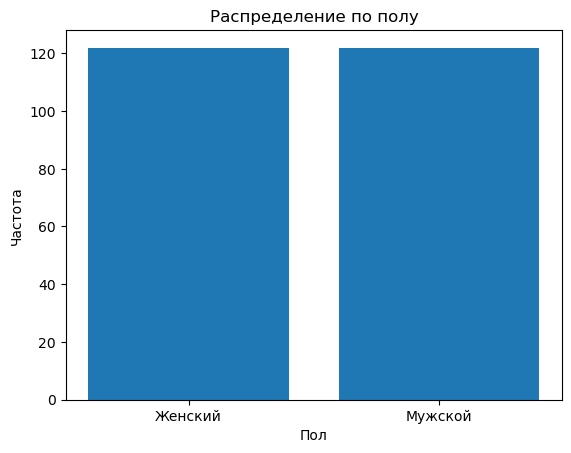

In [ ]:
genders_origin = ds_original.Gender.value_counts()

plt.bar(genders_origin.index, genders_origin.values)
plt.title('Распределение по полу')
plt.xlabel('Пол')
plt.ylabel('Частота')
plt.xticks([0, 1], ['Женский', 'Мужской'])
plt.show()




Можем видеть, что люди разных полов одинаково часта покупают машины, перейду к полю Age все действия буду аналогичны

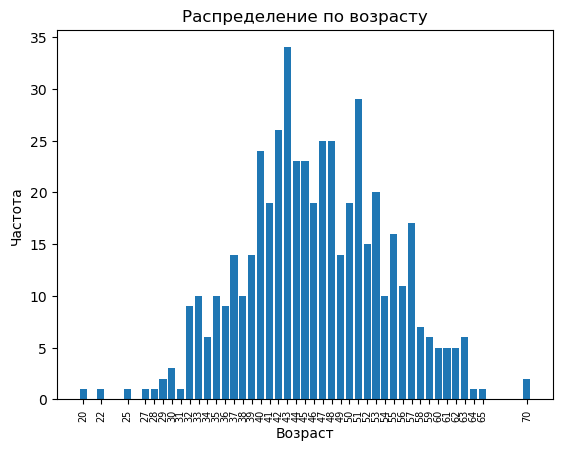

In [ ]:
ages_origin = ds_original.Age.value_counts()
plt.bar(ages_origin.index, ages_origin.values)
plt.title("Распределение по возрасту")
plt.xlabel("Возраст")
plt.xticks(ages_origin.index, rotation=90, fontsize=7) 
plt.ylabel("Частота")
plt.show()

На графике видно, что большая часть людей покупает машины в возрасте 43 лет. Так же в целом можно заметить, что в юном и пожилом возрасте люди покупают машины меньше, это можно связать с финансовыми возмностями в этом возрасте и в отсутствии потребности в приобретении новых автомобилей(это скорей про старшие возраста). 

Перейду к анализу Annual_salary

In [ ]:
annual_salary_origin = ds_original["Annual Salary"].value_counts()
annual_salary_origin = annual_salary_origin.sort_index()

annual_salary_origin

Annual Salary
20000.00000     1
32697.98161     1
33422.99683     1
34154.77654     1
35069.41886     1
               ..
90556.62686     1
91083.73918     1
92455.72807     1
92471.17612     1
100000.00000    1
Name: count, Length: 500, dtype: int64

Как можно видеть, все значения уникальны и по гистограмме оценить распределение нельзя. Я предлагаю объединить значения по десяткам тысяч, то есть первый столбец все 2х_ххх, второй 3х_ххх и т.д. Это поможет примерно поять распределение годовых зарпалт людей и построить по этим данным гистограмму.

In [ ]:
annual_salary_grouped = pd.DataFrame( columns=["20000","30000","40000","50000","60000","70000","80000","90000","100000"], index = ["count"])
annual_salary_grouped.loc["count"] = 0

for index, value in annual_salary_origin.items():
    if index >= 20000 and index < 30000:
        annual_salary_grouped.loc["count", "20000"] += 1
    if index >= 30000 and index < 40000:
        annual_salary_grouped.loc["count", "30000"] += 1
    if index >= 40000 and index < 50000:
        annual_salary_grouped.loc["count", "40000"] += 1
    if index >= 50000 and index < 60000:
        annual_salary_grouped.loc["count", "50000"] += 1
    if index >= 60000 and index < 70000:
        annual_salary_grouped.loc["count", "60000"] += 1
    if index >= 70000 and index < 80000:
        annual_salary_grouped.loc["count", "70000"] += 1
    if index >= 80000 and index < 90000:
        annual_salary_grouped.loc["count", "80000"] += 1
    if index >= 90000 and index < 100000:
        annual_salary_grouped.loc["count", "90000"] += 1
    if index >= 100000 and index < 110000:
        annual_salary_grouped.loc["count", "100000"] += 1

annual_salary_grouped

,20000,30000,40000,50000,60000,70000,80000,90000,100000
count,1,16,58,128,169,100,23,4,1


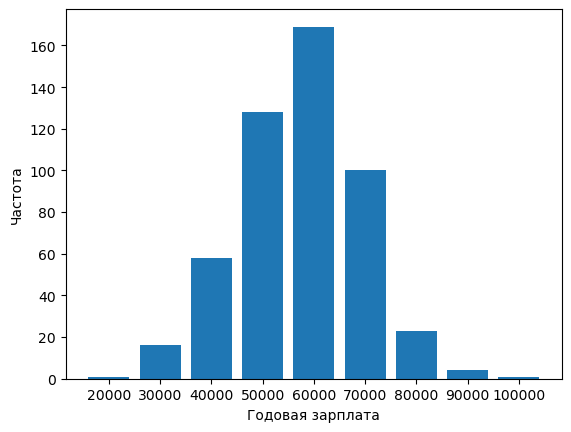

In [17]:
plt.bar(annual_salary_grouped.columns, annual_salary_grouped.values[0])
plt.xlabel("Годовая зарплата")
plt.ylabel("Частота")
plt.show()


На изображении мы можем сделать вывод, что распределение стремится к нормальному и больше всего получают зарплату в размере 60000. 

Далее перейдём к Credit Card Debt, действия будут аналогичные. Только теперь будем использовать функцию cut

In [18]:
credit_card_debt = ds_original["Credit Card Debt"].value_counts()
credit_card_debt = credit_card_debt.sort_index()

credit_card_debt

Credit Card Debt
100.000000      1
594.804949      1
632.052852      1
640.045378      1
861.816653      1
               ..
17870.637650    1
18361.249150    1
18693.146520    1
19692.912620    1
20000.000000    1
Name: count, Length: 500, dtype: int64

In [56]:
a = 500
bins = range(100, 20100, a)
labels = [str(x) for x in bins[:-1]]

credit_card_debt_grouped = pd.cut(credit_card_debt.index,  bins=bins, labels=labels).value_counts()

credit_card_debt_grouped

100       1
600       6
1100      0
1600      4
2100      3
2600      5
3100      3
3600      7
4100      8
4600     14
5100      9
5600     14
6100     16
6600     22
7100     23
7600     29
8100     22
8600     29
9100     28
9600     35
10100    23
10600    32
11100    31
11600    23
12100    18
12600    15
13100    15
13600    15
14100    14
14600     7
15100     8
15600     4
16100     4
16600     3
17100     3
17600     2
18100     1
18600     1
19100     0
Name: count, dtype: int64

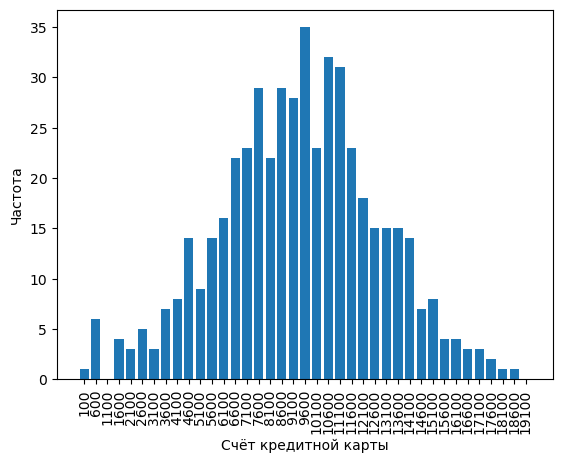

In [55]:
plt.bar(credit_card_debt_grouped.index, credit_card_debt_grouped.values)
plt.xlabel("Счёт кредитной карты")
plt.ylabel("Частота")
plt.xticks( rotation=90) 
plt.show()


Опять видно, что распределение стремится к нормальному и большая часть значений сосредоточена около 9600. Вообще можно преждевременно сделать вывод о том, что все данные стремятся к нормальному распределенью  в этом датасете. Дальше перейдём Net Worth

In [ ]:
net